In [ ]:
"""
Generate and evaluate random linear-system problems for benchmarking.
Sparsity is the proportion of non-zero elements in the matrix. (0 = dense, 1 = sparse)
"""

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p


_repo_root = _find_repo_root()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from linear_systems_problems.random_matrix_generator_v2 import generate_problem

In [10]:
problem_sizes = [2, 4, 8, 16, 32, 64]
cond_numbers = [1, 5, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7]
sparsity_values = [0.1, 0.3, 0.5, 0.7, 0.9]
instances_per_combo = 10

rows = []

for n in problem_sizes:
    for cond_req in cond_numbers:
        for sparsity_req in sparsity_values:
            for seed in range(instances_per_combo):
                prob = generate_problem(
                    n=n,
                    cond_number=cond_req,
                    sparsity=sparsity_req,
                    seed=seed,
                )
                rows.append(
                    {
                        "n": n,
                        "requested_condition": cond_req,
                        "actual_condition": prob["condition_number"],
                        "requested_sparsity": sparsity_req,
                        "actual_sparsity": prob["sparsity"],
                    }
                )

results_df = pd.DataFrame(rows)
print(f"Generated {len(results_df)} problems")
results_df.head()

Generated 4800 problems


,n,requested_condition,actual_condition,requested_sparsity,actual_sparsity
0,2,1.0,1.0,0.1,0.5
1,2,1.0,1.0,0.1,0.5
2,2,1.0,1.0,0.1,0.5
3,2,1.0,1.0,0.1,0.5
4,2,1.0,1.0,0.1,0.5


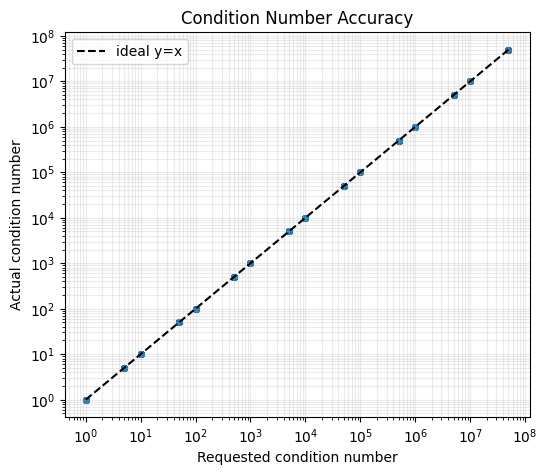

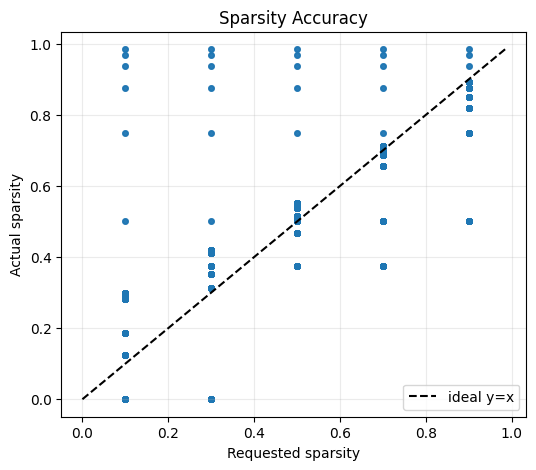

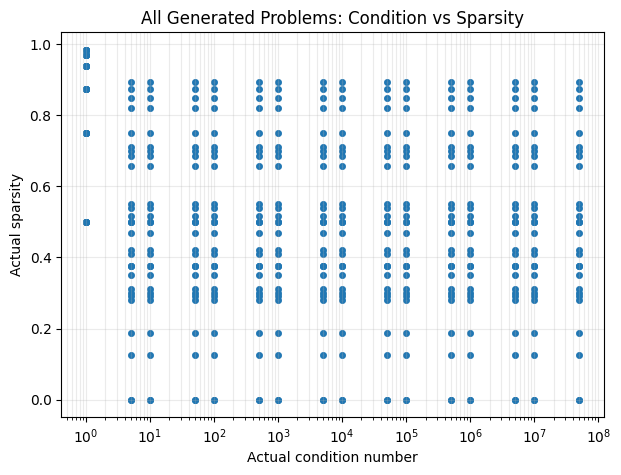

In [11]:
# 1) Requested condition number vs actual condition number
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    results_df["requested_condition"],
    results_df["actual_condition"],
    alpha=0.25,
    s=14,
)
cond_min = min(results_df["requested_condition"].min(), results_df["actual_condition"].min())
cond_max = max(results_df["requested_condition"].max(), results_df["actual_condition"].max())
ax.plot([cond_min, cond_max], [cond_min, cond_max], "k--", lw=1.5, label="ideal y=x")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Requested condition number")
ax.set_ylabel("Actual condition number")
ax.set_title("Condition Number Accuracy")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
plt.show()

# 2) Requested sparsity vs actual sparsity
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    results_df["requested_sparsity"],
    results_df["actual_sparsity"],
    alpha=0.25,
    s=14,
)
s_min = min(results_df["requested_sparsity"].min(), results_df["actual_sparsity"].min())
s_max = max(results_df["requested_sparsity"].max(), results_df["actual_sparsity"].max())
ax.plot([s_min, s_max], [s_min, s_max], "k--", lw=1.5, label="ideal y=x")
ax.set_xlabel("Requested sparsity")
ax.set_ylabel("Actual sparsity")
ax.set_title("Sparsity Accuracy")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

# 3) Scatter of actual condition numbers and actual sparsities for all generated problems
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    results_df["actual_condition"],
    results_df["actual_sparsity"],
    alpha=0.25,
    s=14,
)
ax.set_xscale("log")
ax.set_xlabel("Actual condition number")
ax.set_ylabel("Actual sparsity")
ax.set_title("All Generated Problems: Condition vs Sparsity")
ax.grid(True, which="both", alpha=0.25)
plt.show()

In [12]:
# Optional quantitative accuracy summary
results_df["cond_ratio"] = results_df["actual_condition"] / results_df["requested_condition"]
results_df["sparsity_error"] = results_df["actual_sparsity"] - results_df["requested_sparsity"]

print("Condition ratio (actual/requested):")
print(results_df["cond_ratio"].describe())
print("\nSparsity error (actual-requested):")
print(results_df["sparsity_error"].describe())

Condition ratio (actual/requested):
count    4.800000e+03
mean     1.000000e+00
std      4.451990e-08
min      9.999995e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000002e+00
Name: cond_ratio, dtype: float64

Sparsity error (actual-requested):
count    4800.000000
mean       -0.000351
std         0.181667
min        -0.400000
25%        -0.079688
50%         0.000000
75%         0.075000
max         0.884375
Name: sparsity_error, dtype: float64
